In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers
import keras
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


# LOAD DATA

In [3]:
train_path ='/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/train'
test_path ='/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/test'
val_path ='/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/val'

In [4]:
import os

train_dir = r"/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/train"

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        print(f"{cls}: {len(images)}")

Calculus: 907
Data caries: 1667
Gingivitis: 1644
Mouth Ulcer: 1778
Tooth Discoloration: 1283
hypodontia: 875


In [5]:
import os

val_dir = r"/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/val"

for cls in sorted(os.listdir(val_dir)):
    cls_path = os.path.join(val_dir, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

Calculus 194
Data caries 357
Gingivitis 352
Mouth Ulcer 381
Tooth Discoloration 275
hypodontia 187


In [6]:
import os

dataset_path = r"/kaggle/input/datasets/omarsalman77/oral-disease/dataset2"

for split in ["train", "val", "test"]:
    total = 0
    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))

    print(f"{split} Total Images = {total}")

train Total Images = 8154
val Total Images = 1746
test Total Images = 1753


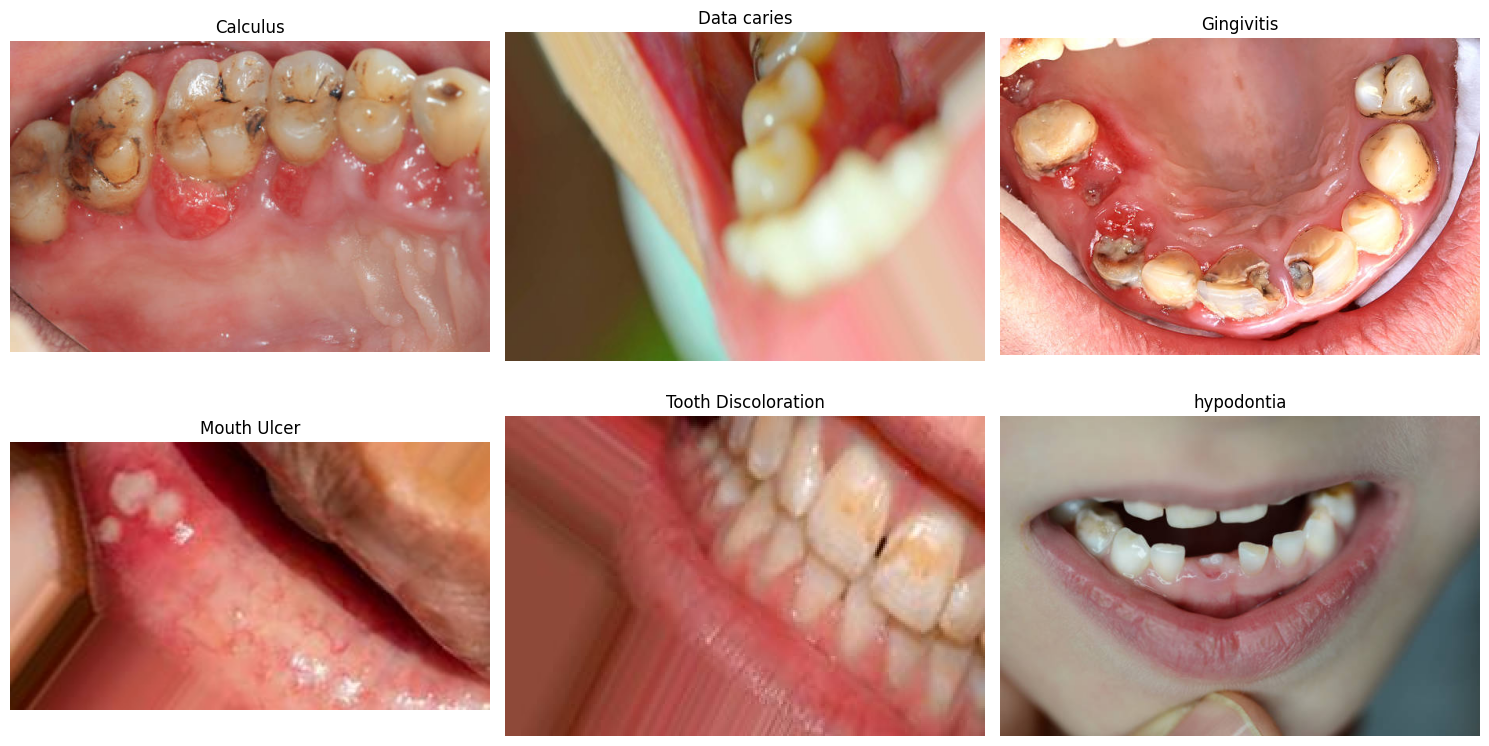

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_path = r"/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/train"

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]

    img = Image.open(os.path.join(cls_path, images[0]))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from PIL import Image
import os

train_path = r"/kaggle/input/datasets/omarsalman77/oral-disease/dataset2/train"

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]

    img = Image.open(os.path.join(cls_path, images[0]))

    print(f"{cls} --> Size: {img.size}")

Data caries --> Size: (612, 420)
Mouth Ulcer --> Size: (300, 168)
Tooth Discoloration --> Size: (240, 160)
hypodontia --> Size: (612, 408)
Gingivitis --> Size: (612, 404)
Calculus --> Size: (612, 397)


In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [10]:
train_ds = image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8154 files belonging to 6 classes.


I0000 00:00:1783989906.995359      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783989906.998178      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1746 files belonging to 6 classes.
Found 1753 files belonging to 6 classes.


In [11]:
class_names = train_ds.class_names
print(class_names)

['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']


In [12]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# نحسب class_weight من الـ train_ds الأصلي (قبل أي تعديل تاني) عشان نستخدمه مع كل الموديلات
y_train = np.concatenate([labels.numpy() for _, labels in train_ds])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.4983461962513782), 1: np.float64(0.8152369526094781), 2: np.float64(0.8266423357664233), 3: np.float64(0.764341957255343), 4: np.float64(1.059236165237724), 5: np.float64(1.5531428571428572)}


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def get_callbacks(model_name):
    """بترجع لستة callbacks جاهزة لأي موديل، مع اسم مختلف لكل موديل عشان نحفظه في ملف منفصل"""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ]


In [14]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [15]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# CUSTOM CNN

In [17]:
model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,270 (50.49 MB)

 Trainable params: 13,235,270 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=get_callbacks("custom_cnn")
)


Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.3733 - loss: 1.4727 - val_accuracy: 0.4462 - val_loss: 1.2340 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.4827 - loss: 1.1978 - val_accuracy: 0.5212 - val_loss: 1.0345 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.5335 - loss: 1.0934 - val_accuracy: 0.6271 - val_loss: 0.9050 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.5612 - loss: 1.0055 - val_accuracy: 0.5985 - val_loss: 0.9011 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.5980 - loss: 0.9468 - val_accuracy: 0.6340 - val_loss: 0.8445 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.6038 - loss: 0.9193 - val_accuracy: 0.5951 - val_loss: 0.8393 - learning_rate: 0.0010
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.6193 - l

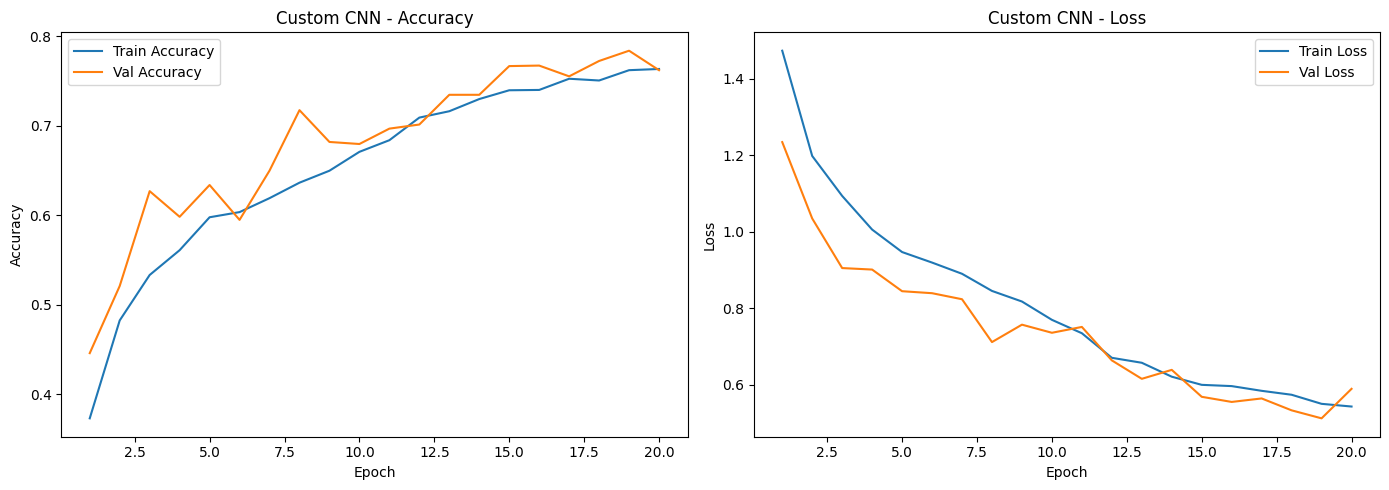

In [21]:
plot_history(history, "Custom CNN")


In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [23]:
def evaluate_model(model, test_ds, class_names):

    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Classification Report:

                     precision    recall  f1-score   support

           Calculus     0.5858    0.8051    0.6782       195
        Data caries     0.7232    0.7737    0.7476       358
         Gingivitis     0.8019    0.7110    0.7538       353
        Mouth Ulcer     0.9251    0.9058    0.9153       382
Tooth Discoloration     0.8333    0.6341    0.7202       276
         hypodontia     0.8732    0.9471    0.9086       189

           accuracy                         0.7901      1753
          macro avg     0.7904    0.7961    0.7873      1753
       weighted avg     0.8013    0.7901    0.7907      1753



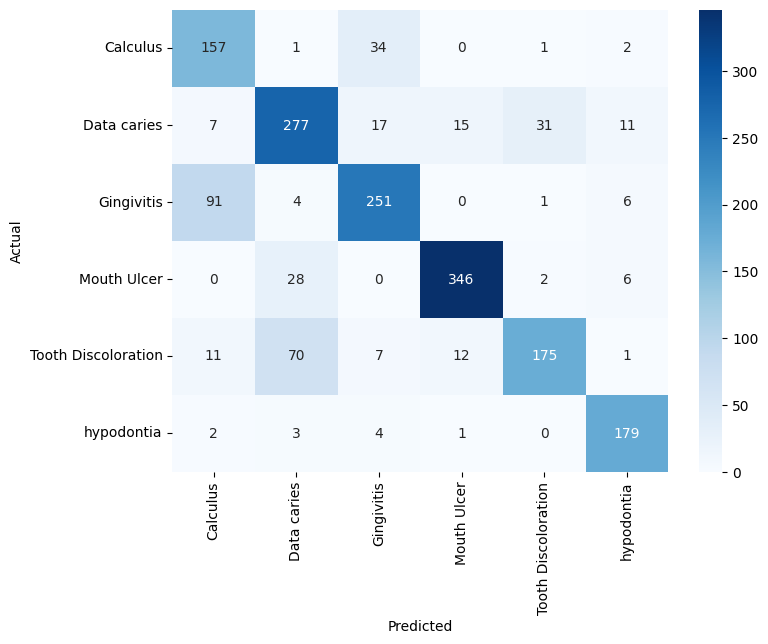

In [24]:
evaluate_model(
    model,
    test_ds,
    class_names
)

In [25]:
train_ds_pre = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

val_ds_pre = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32
)

test_ds_pre = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32
)

Found 8154 files belonging to 6 classes.
Found 1746 files belonging to 6 classes.
Found 1753 files belonging to 6 classes.


In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model_mobilenet = models.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(6, activation='softmax')
])

model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
history_mobile = model_mobilenet.fit(
    train_ds_pre,
    validation_data=val_ds_pre,
    epochs=20,
    class_weight=class_weights,
    callbacks=get_callbacks("mobilenet")
)


Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 25s 76ms/step - accuracy: 0.3879 - loss: 1.4327 - val_accuracy: 0.4450 - val_loss: 1.2690 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.4398 - loss: 1.2790 - val_accuracy: 0.4800 - val_loss: 1.2672 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.4688 - loss: 1.2261 - val_accuracy: 0.4771 - val_loss: 1.1904 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.4852 - loss: 1.1845 - val_accuracy: 0.4450 - val_loss: 1.1912 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.4899 - loss: 1.1763 - val_accuracy: 0.4645 - val_loss: 1.1421 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.5059 - loss: 1.1464 - val_accuracy: 0.4530 - val_loss: 1.1874 - learning_rate: 0.0010
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.5048 - l

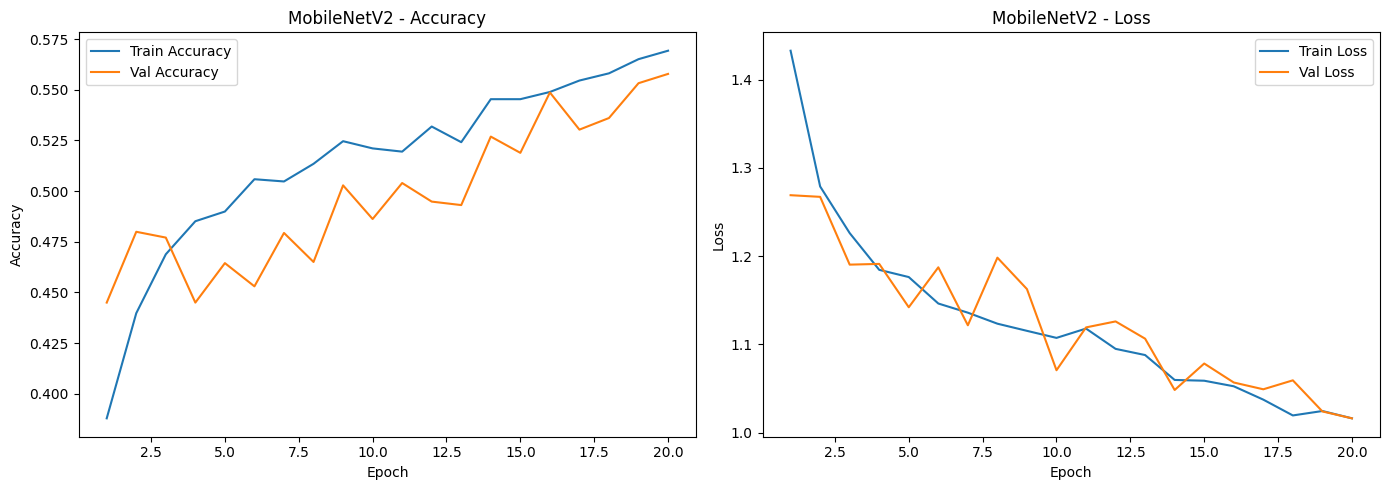

In [28]:
plot_history(history_mobile, "MobileNetV2")


In [29]:
test_loss, test_acc = model_mobilenet.evaluate(test_ds_pre)

print(f"Test Accuracy : {test_acc:.4f}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5339 - loss: 1.0297
Test Accuracy : 0.5339



Classification Report:

                     precision    recall  f1-score   support

           Calculus     0.3030    0.6308    0.4093       195
        Data caries     0.5306    0.5084    0.5193       358
         Gingivitis     0.5669    0.4079    0.4745       353
        Mouth Ulcer     0.7254    0.6571    0.6896       382
Tooth Discoloration     0.5367    0.4239    0.4737       276
         hypodontia     0.6398    0.6296    0.6347       189

           accuracy                         0.5339      1753
          macro avg     0.5504    0.5429    0.5335      1753
       weighted avg     0.5678    0.5339    0.5404      1753



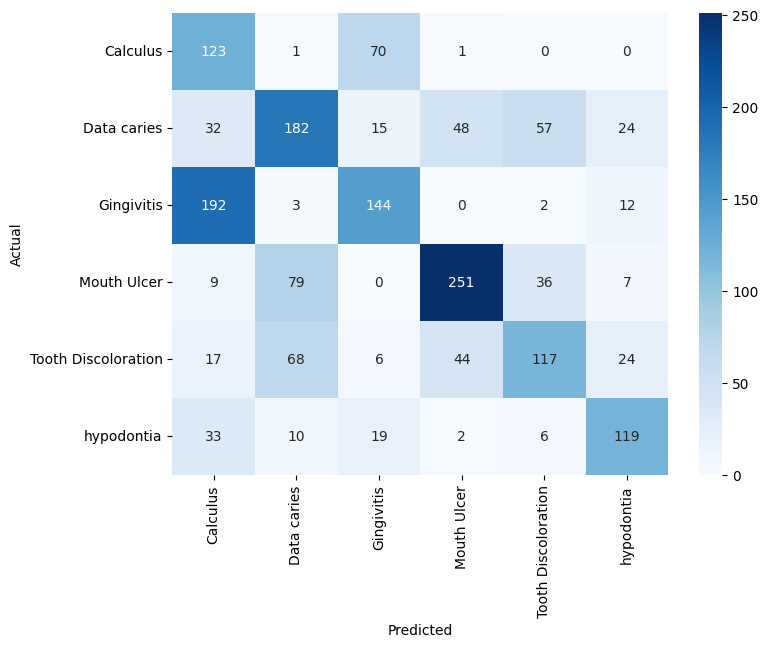

In [30]:
evaluate_model(
    model_mobilenet,
    test_ds_pre,
    class_names
)

In [31]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model_resnet = tf.keras.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(6, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_ds_pre,
    validation_data=val_ds_pre,
    epochs=20,
    class_weight=class_weights,
    callbacks=get_callbacks("resnet")
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 54s 180ms/step - accuracy: 0.5795 - loss: 1.0678 - val_accuracy: 0.7050 - val_loss: 0.6807 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.6901 - loss: 0.7469 - val_accuracy: 0.7887 - val_loss: 0.5451 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.7237 - loss: 0.6660 - val_accuracy: 0.7915 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 163ms/step - accuracy: 0.7468 - loss: 0.6132 - val_accuracy: 0.7938 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 42s 163ms/step - accuracy: 0.7470 - loss: 0.6001 - val_accuracy: 0.8150 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.7737 - loss: 0.5506 - val_accuracy: 0.7749 - val_loss: 0.5035 - learning_rate: 0.0010
Epoch 7/20
255/255 

55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.8842 - loss: 0.2814

Classification Report:

                     precision    recall  f1-score   support

           Calculus     0.6479    0.7077    0.6765       195
        Data caries     0.9314    0.9106    0.9209       358
         Gingivitis     0.8120    0.8074    0.8097       353
        Mouth Ulcer     0.9712    0.9712    0.9712       382
Tooth Discoloration     0.9326    0.9022    0.9171       276
         hypodontia     0.9526    0.9577    0.9551       189

           accuracy                         0.8842      1753
          macro avg     0.8746    0.8761    0.8751      1753
       weighted avg     0.8870    0.8842    0.8854      1753



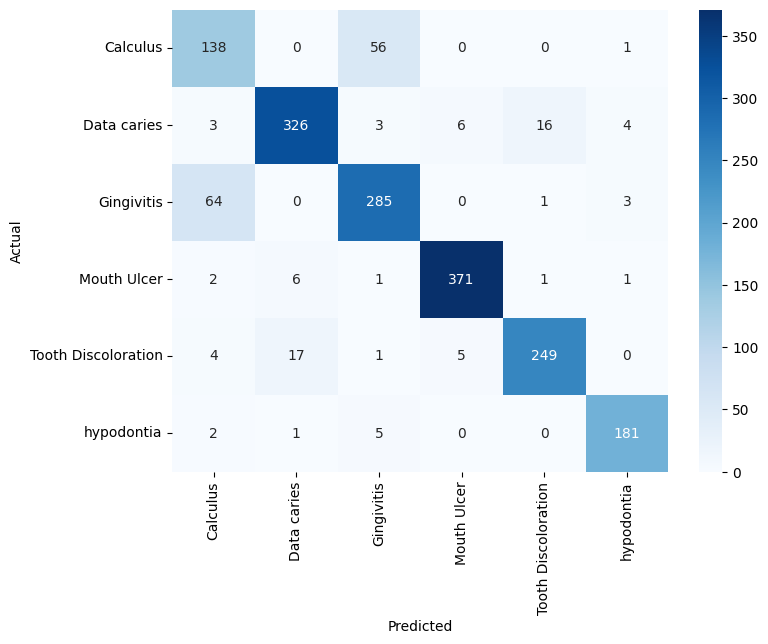

In [32]:
test_loss, test_acc = model_resnet.evaluate(test_ds_pre)

evaluate_model(
    model_resnet,
    test_ds_pre,
    class_names
)

In [33]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model_eff = tf.keras.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(6, activation='softmax')
])

model_eff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_eff = model_eff.fit(
    train_ds_pre,
    validation_data=val_ds_pre,
    epochs=20,
    class_weight=class_weights,
    callbacks=get_callbacks("efficientnet")
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


E0000 00:00:1783991523.393953      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


255/255 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.6654 - loss: 0.8335 - val_accuracy: 0.7887 - val_loss: 0.5103 - learning_rate: 0.0010
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.7658 - loss: 0.5872 - val_accuracy: 0.8162 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7962 - loss: 0.4978 - val_accuracy: 0.8310 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.8232 - loss: 0.4466 - val_accuracy: 0.8431 - val_loss: 0.3590 - learning_rate: 0.0010
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.8370 - loss: 0.4053 - val_accuracy: 0.8591 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.8377 - loss: 0.3938 - val_accuracy: 0.8711 - val_loss: 0.3076 - learning_rate: 0.0010
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.8489 - loss: 0.378

55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9167 - loss: 0.1832

Classification Report:

                     precision    recall  f1-score   support

           Calculus     0.6733    0.6974    0.6851       195
        Data caries     0.9803    0.9749    0.9776       358
         Gingivitis     0.8244    0.8244    0.8244       353
        Mouth Ulcer     0.9948    0.9921    0.9934       382
Tooth Discoloration     0.9713    0.9819    0.9766       276
         hypodontia     0.9945    0.9577    0.9757       189

           accuracy                         0.9167      1753
          macro avg     0.9064    0.9047    0.9055      1753
       weighted avg     0.9180    0.9167    0.9173      1753



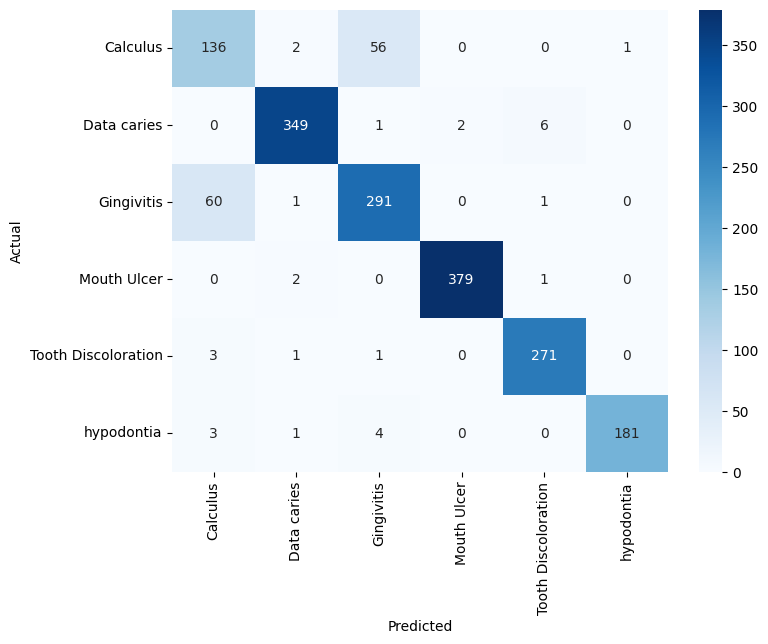

In [34]:
test_loss, test_acc = model_eff.evaluate(test_ds_pre)

evaluate_model(
    model_eff,
    test_ds_pre,
    class_names
)

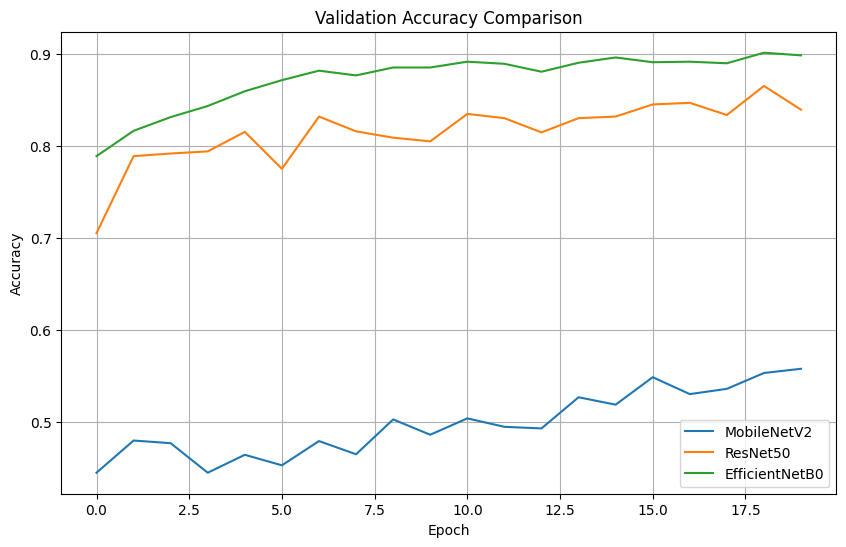

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50')
plt.plot(history_eff.history['val_accuracy'], label='EfficientNetB0')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

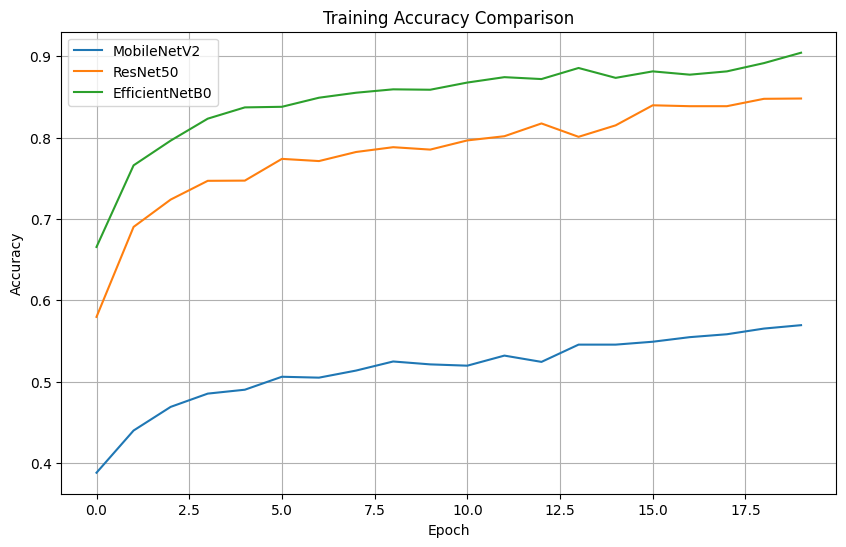

In [36]:
plt.figure(figsize=(10,6))

plt.plot(history_mobile.history['accuracy'], label='MobileNetV2')
plt.plot(history_resnet.history['accuracy'], label='ResNet50')
plt.plot(history_eff.history['accuracy'], label='EfficientNetB0')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

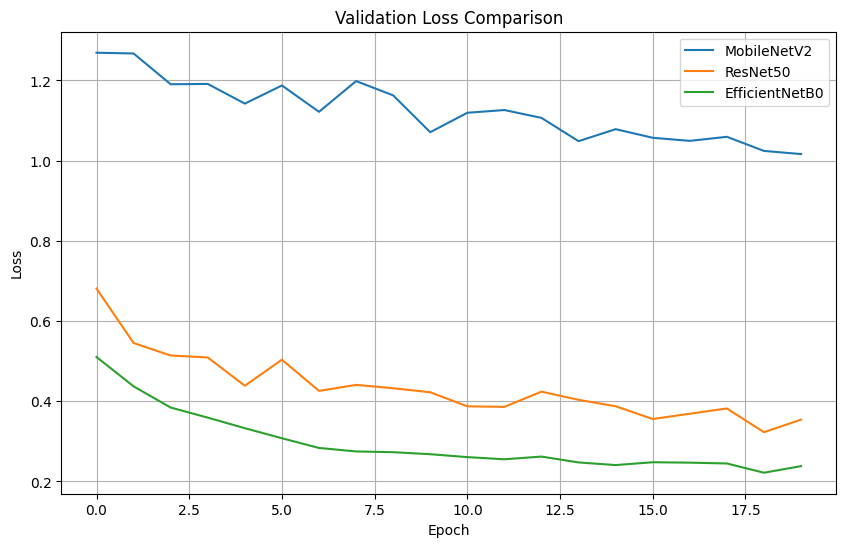

In [37]:
plt.figure(figsize=(10,6))

plt.plot(history_mobile.history['val_loss'], label='MobileNetV2')
plt.plot(history_resnet.history['val_loss'], label='ResNet50')
plt.plot(history_eff.history['val_loss'], label='EfficientNetB0')

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

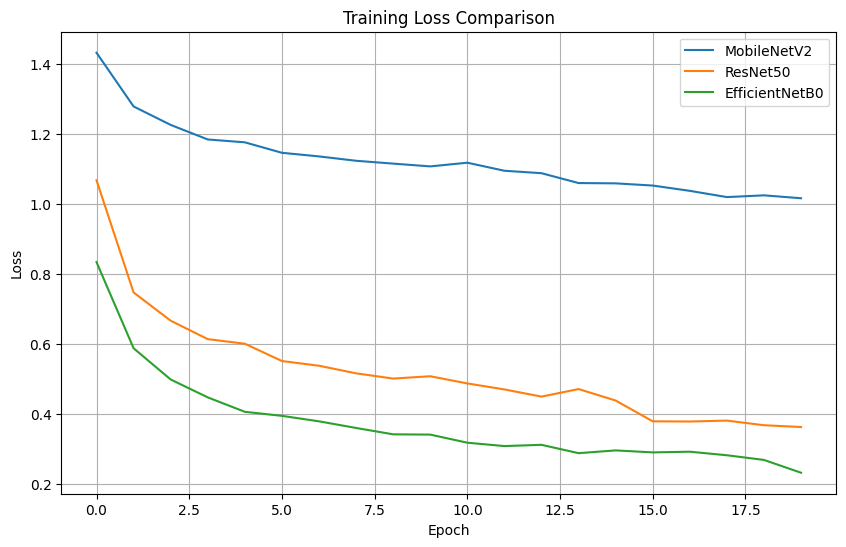

In [38]:
plt.figure(figsize=(10,6))

plt.plot(history_mobile.history['loss'], label='MobileNetV2')
plt.plot(history_resnet.history['loss'], label='ResNet50')
plt.plot(history_eff.history['loss'], label='EfficientNetB0')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
mobile_acc = model_mobilenet.evaluate(test_ds_pre, verbose=0)[1]
resnet_acc = model_resnet.evaluate(test_ds_pre, verbose=0)[1]
eff_acc = model_eff.evaluate(test_ds_pre, verbose=0)[1]

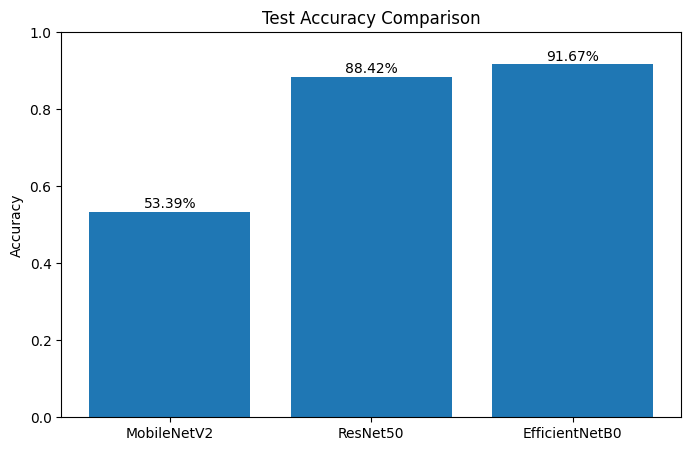

In [40]:
models = ["MobileNetV2", "ResNet50", "EfficientNetB0"]
accuracies = [mobile_acc, resnet_acc, eff_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.01, f"{acc:.2%}", ha='center')

plt.show()

In [41]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

best_model = load_model(
    "best_efficientnet.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

In [ ]:
model.save_weights("efficientnet.weights.h5")